# EV Simulator — Validation Notebook

Four checks:
1. One representative user per archetype — full week SoC and charging power
2. Population key stats by 2-hour bloc — typical day view
3. Per-archetype breakdown of the same stats
4. Intelligent Octopus: charging behaviour vs day-ahead price

> **Note:** Plot 4 requires price data. Run `python scripts/fetch_prices.py` first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict

from ev_simulator.simulation import Simulator
from ev_simulator.constants import N_SIMULATION_DAYS, HALF_HOUR_PERIODS_PER_DAY

N_PERIODS = N_SIMULATION_DAYS * HALF_HOUR_PERIODS_PER_DAY
PERIODS_PER_BLOC = 4   # half-hours in a 2-hour bloc
N_BLOCS = HALF_HOUR_PERIODS_PER_DAY // PERIODS_PER_BLOC  # 12
BLOC_LABELS = [f"{h:02d}:00" for h in range(0, 24, 2)]

sim = Simulator(n_users=2000, seed=42)
result = sim.run()

counts = defaultdict(int)
for u in result.users:
    counts[u.archetype.name] += 1
print(f"Simulated {len(result.users)} users")
for name, n in sorted(counts.items()):
    print(f"  {name}: {n}")

Simulated 2000 users
  Always plugged-in: 20
  Average (UK): 777
  Infrequent charging: 188
  Infrequent driving: 222
  Intelligent Octopus average: 602
  Scheduled charging: 191


## 1. Individual user per archetype

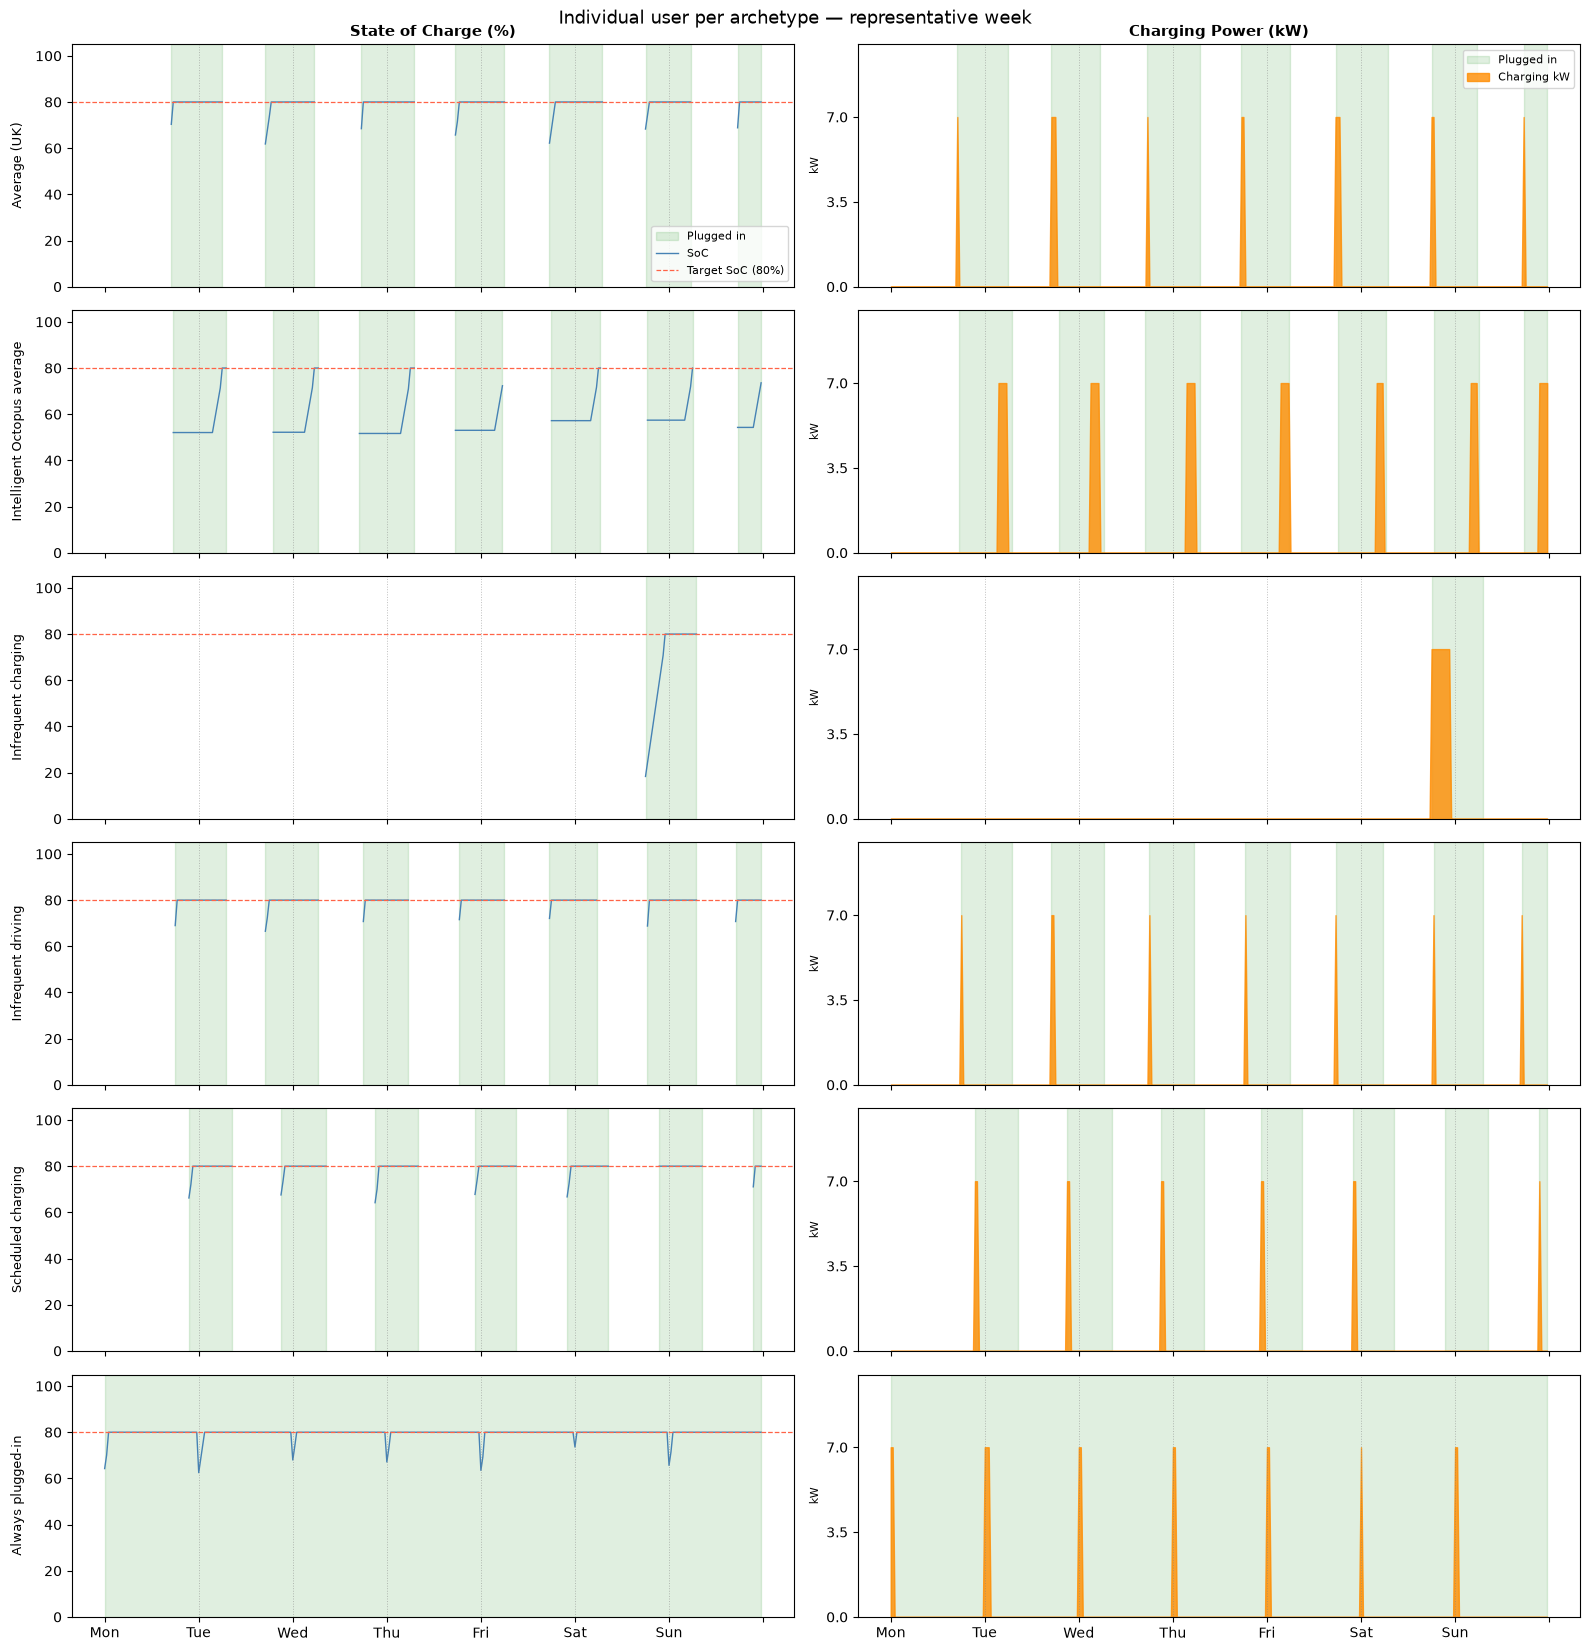

In [2]:
# Pick first user of each archetype
seen = {}
for u in result.users:
    if u.archetype.name not in seen:
        seen[u.archetype.name] = u.user_id

archetype_names = list(seen.keys())
n_arch = len(archetype_names)
t_hours = np.arange(N_PERIODS) * 0.5  # hours since Monday 00:00
day_ticks = np.arange(0, N_SIMULATION_DAYS + 1) * 24
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", ""]

fig, axes = plt.subplots(n_arch, 2, figsize=(16, 2.8 * n_arch), sharex=True)
fig.suptitle("Individual user per archetype — representative week", fontsize=13)

axes[0, 0].set_title("State of Charge (%)", fontsize=11, fontweight="bold")
axes[0, 1].set_title("Charging Power (kW)", fontsize=11, fontweight="bold")

for row, name in enumerate(archetype_names):
    uid = seen[name]
    ax_soc, ax_kw = axes[row]

    ax_soc.set_ylabel(name, fontsize=9, labelpad=8)

    plugged = result.plugged_in[uid].astype(bool)
    soc_visible = np.where(plugged, result.soc[uid] * 100, np.nan)  # NaN outside plug-in window → gap in line

    ax_soc.fill_between(t_hours, 0, 105, where=plugged, alpha=0.12, color="green", label="Plugged in")
    ax_soc.plot(t_hours, soc_visible, color="steelblue", linewidth=1, label="SoC")
    ax_soc.axhline(80, color="tomato", linestyle="--", linewidth=0.9, label="Target SoC (80%)")
    ax_soc.set_ylim(0, 105)
    ax_soc.set_yticks([0, 20, 40, 60, 80, 100])

    ax_kw.fill_between(t_hours, 0, 10, where=plugged, alpha=0.12, color="green", label="Plugged in")
    ax_kw.fill_between(t_hours, result.charging_kw[uid], color="darkorange", alpha=0.8, label="Charging kW")
    ax_kw.set_ylim(0, 10)
    ax_kw.set_yticks([0, 3.5, 7])
    ax_kw.set_ylabel("kW", fontsize=8)

    if row == 0:
        ax_soc.legend(fontsize=8, loc="lower right")
        ax_kw.legend(fontsize=8, loc="upper right")

    for ax in (ax_soc, ax_kw):
        for d in range(1, N_SIMULATION_DAYS):
            ax.axvline(d * 24, color="grey", linestyle=":", linewidth=0.7, alpha=0.5)

axes[-1, 0].set_xticks(day_ticks)
axes[-1, 0].set_xticklabels(day_labels)
axes[-1, 1].set_xticks(day_ticks)
axes[-1, 1].set_xticklabels(day_labels)

plt.tight_layout()
plt.show()


## 2. Population key stats — typical day (2-hour blocs)

/var/folders/fh/zr_80q754zxdsrjxhz76xqs40000gn/T/ipykernel_26870/3153448370.py:8: RuntimeWarning: Mean of empty slice
  by_day = np.nanmean(arr.reshape(-1, N_SIMULATION_DAYS, HALF_HOUR_PERIODS_PER_DAY), axis=1)
/var/folders/fh/zr_80q754zxdsrjxhz76xqs40000gn/T/ipykernel_26870/3153448370.py:9: RuntimeWarning: Mean of empty slice
  return np.nanmean(by_day.reshape(-1, N_BLOCS, PERIODS_PER_BLOC), axis=2)


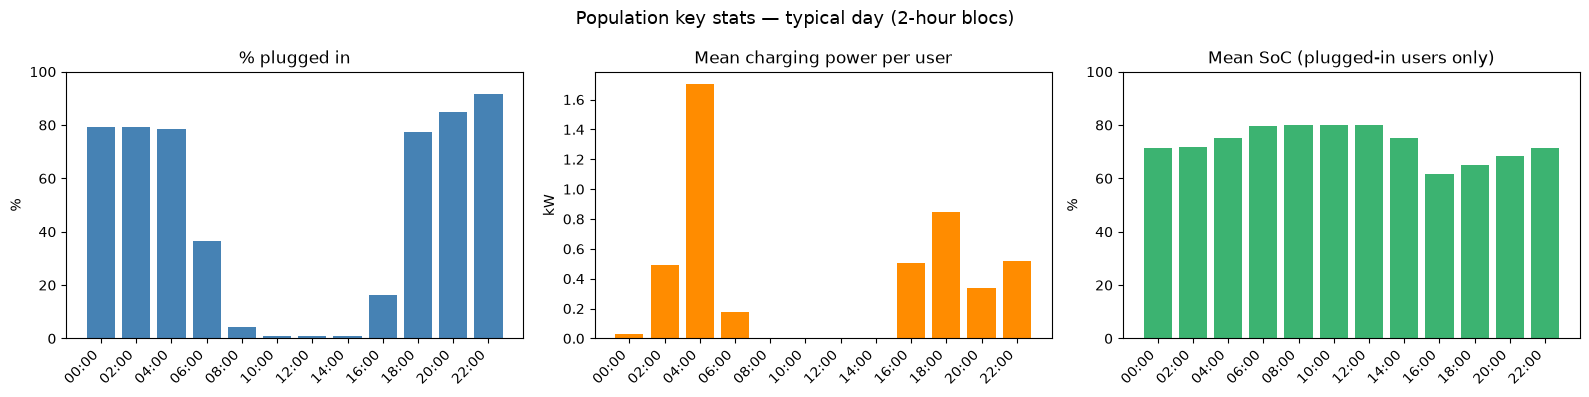

In [3]:
def to_typical_day_blocs(arr: np.ndarray) -> np.ndarray:
    """(N_users, 336) → (N_users, 12) averaged over days and grouped into 2-hour blocs."""
    by_day = arr.reshape(-1, N_SIMULATION_DAYS, HALF_HOUR_PERIODS_PER_DAY).mean(axis=1)
    return by_day.reshape(-1, N_BLOCS, PERIODS_PER_BLOC).mean(axis=2)

def to_typical_day_blocs_nan(arr: np.ndarray) -> np.ndarray:
    """NaN-aware version: NaN periods are excluded from the mean rather than dragging it towards 0 or SOC_CAP."""
    by_day = np.nanmean(arr.reshape(-1, N_SIMULATION_DAYS, HALF_HOUR_PERIODS_PER_DAY), axis=1)
    return np.nanmean(by_day.reshape(-1, N_BLOCS, PERIODS_PER_BLOC), axis=2)

pi_blocs  = to_typical_day_blocs(result.plugged_in.astype(float))
ck_blocs  = to_typical_day_blocs(result.charging_kw)

# Mask SoC to NaN when not plugged in so unconnected periods don't inflate the mean
soc_masked = np.where(result.plugged_in, result.soc, np.nan)
soc_blocs  = to_typical_day_blocs_nan(soc_masked)

x = np.arange(N_BLOCS)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Population key stats — typical day (2-hour blocs)", fontsize=13)

axes[0].bar(x, pi_blocs.mean(axis=0) * 100, color="steelblue")
axes[0].set_title("% plugged in")
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 100)

axes[1].bar(x, ck_blocs.mean(axis=0), color="darkorange")
axes[1].set_title("Mean charging power per user")
axes[1].set_ylabel("kW")

axes[2].bar(x, np.nanmean(soc_blocs, axis=0) * 100, color="mediumseagreen")
axes[2].set_title("Mean SoC (plugged-in users only)")
axes[2].set_ylabel("%")
axes[2].set_ylim(0, 100)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(BLOC_LABELS, rotation=45, ha="right")

plt.tight_layout()
plt.show()


## 3. Per-archetype breakdown — typical day

/var/folders/fh/zr_80q754zxdsrjxhz76xqs40000gn/T/ipykernel_26870/3438642627.py:29: RuntimeWarning: Mean of empty slice
  values = np.nanmean(subset, axis=0) if use_nan else subset.mean(axis=0)
/Users/sarahinman/miniconda3/envs/ev_simulator/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/fh/zr_80q754zxdsrjxhz76xqs40000gn/T/ipykernel_26870/3438642627.py:29: RuntimeWarning: Mean of empty slice
  values = np.nanmean(subset, axis=0) if use_nan else subset.mean(axis=0)
/Users/sarahinman/miniconda3/envs/ev_simulator/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/fh/zr_80q754zxdsrjxhz76xqs40000gn/T/ipykernel_26870/3438642627.py:29: RuntimeWarning: Mean of empty slice
  values = np.nanmean(subset, axis=0) if 

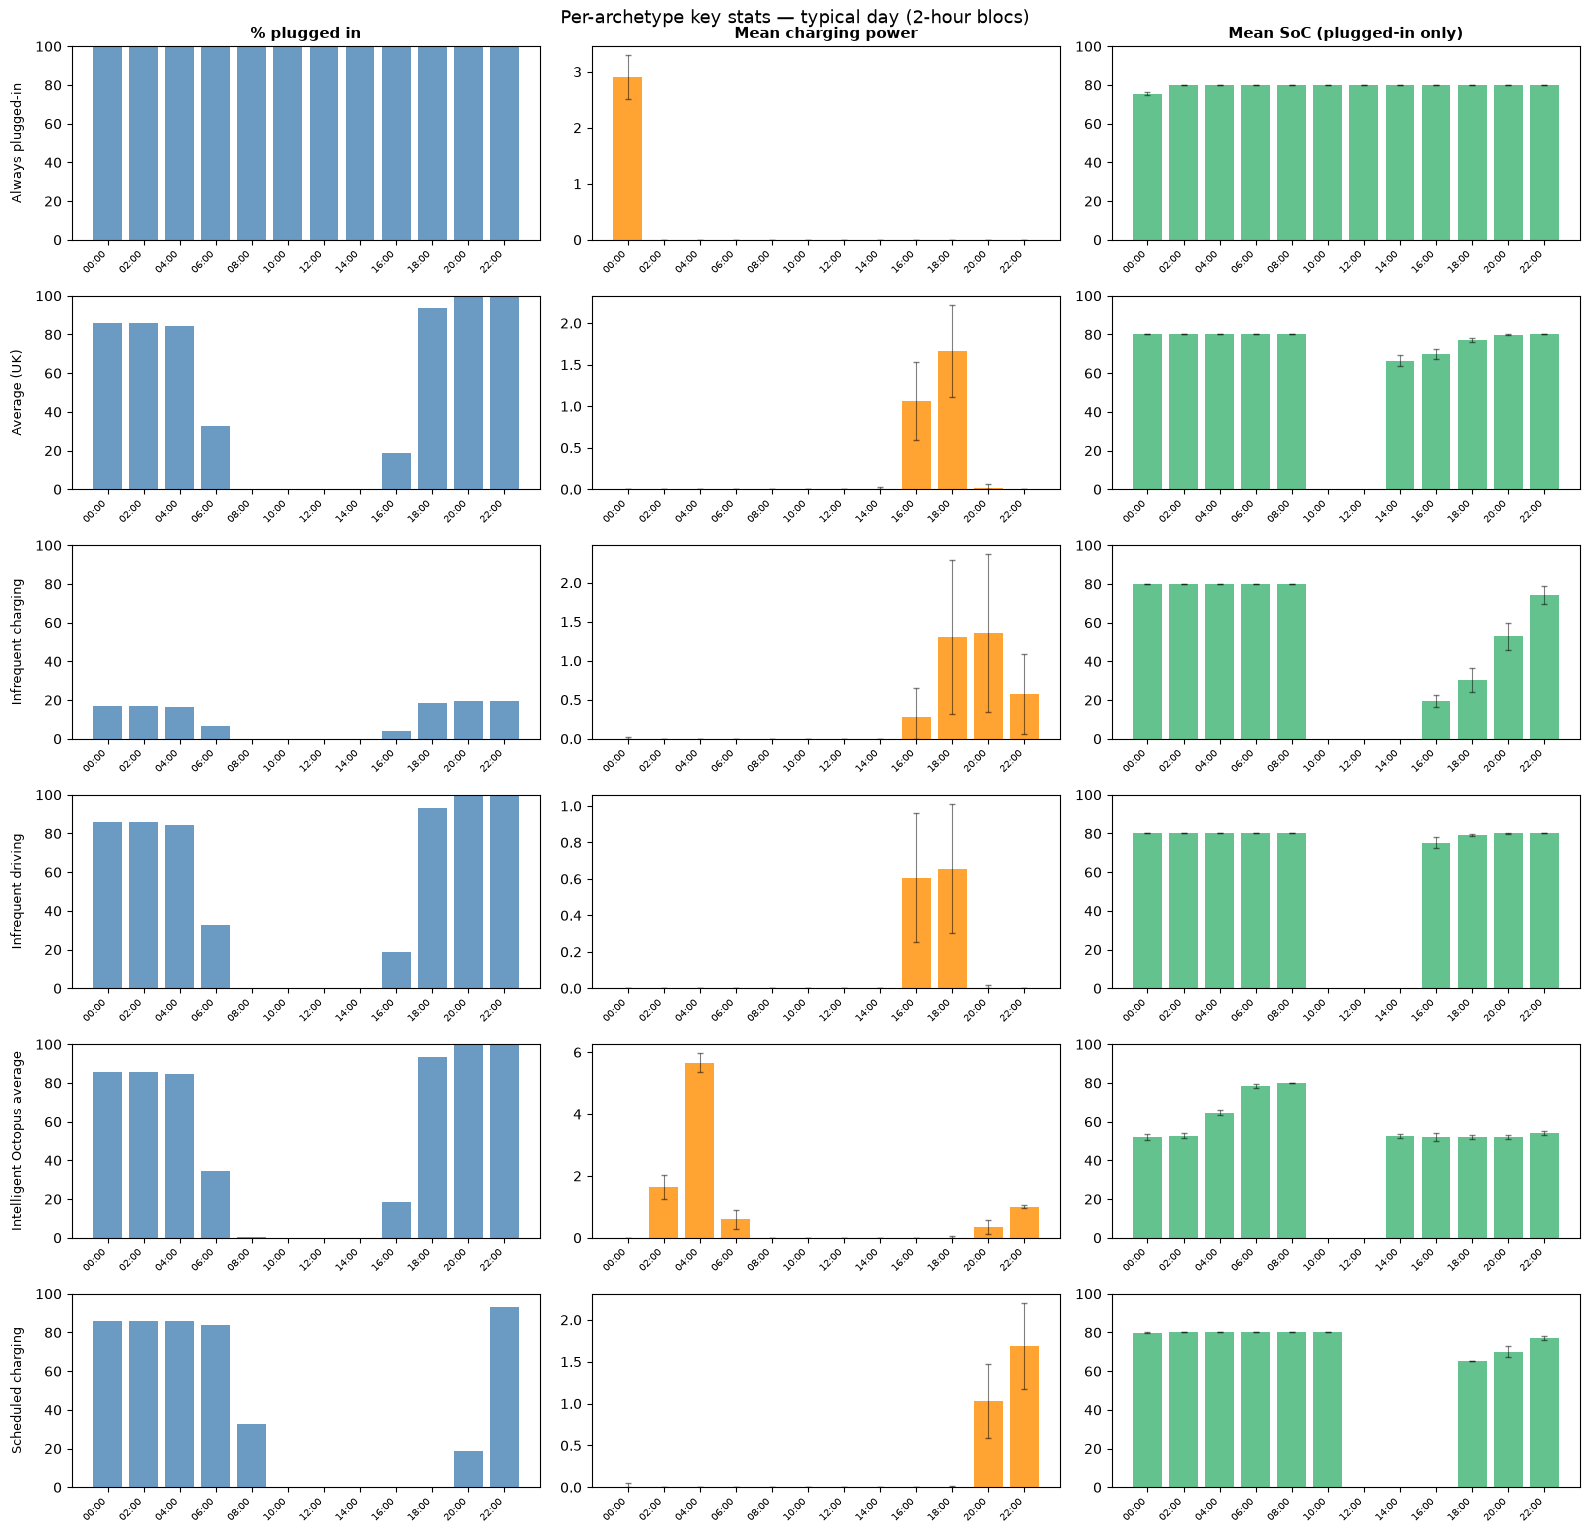

In [4]:
archetype_indices = defaultdict(list)
for u in result.users:
    archetype_indices[u.archetype.name].append(u.user_id)

arch_names = sorted(archetype_indices.keys())
n_arch = len(arch_names)
x = np.arange(N_BLOCS)

# (title, blocs, unit, ylim, color, use_nan, show_error_bars)
col_specs = [
    ("% plugged in",                pi_blocs,  "%",   (0, 100), "steelblue",      False, False),
    ("Mean charging power",         ck_blocs,  "kW",  None,     "darkorange",     False, True),
    ("Mean SoC (plugged-in only)",  soc_blocs, "%",   (0, 100), "mediumseagreen", True,  True),
]

fig, axes = plt.subplots(n_arch, 3, figsize=(16, 2.6 * n_arch), sharex=False)
fig.suptitle("Per-archetype key stats — typical day (2-hour blocs)", fontsize=13)

for col, (title, *_) in enumerate(col_specs):
    axes[0, col].set_title(title, fontsize=11, fontweight="bold")

for row, name in enumerate(arch_names):
    indices = archetype_indices[name]
    axes[row, 0].set_ylabel(name, fontsize=9, labelpad=8)

    for col, (_, blocs, unit, ylim, color, use_nan, show_err) in enumerate(col_specs):
        ax = axes[row, col]
        subset = blocs[indices]
        values = np.nanmean(subset, axis=0) if use_nan else subset.mean(axis=0)
        if unit == "%":
            values = values * 100

        yerr = None
        if show_err:
            err = np.nanstd(subset, axis=0) if use_nan else subset.std(axis=0)
            if unit == "%":
                err = err * 100
            # clip lower bar so it never extends below zero
            yerr = [np.minimum(err, values), err]

        ax.bar(x, values, color=color, alpha=0.8, yerr=yerr,
               error_kw={"linewidth": 0.8, "capsize": 2, "color": "black", "alpha": 0.5})
        if ylim:
            ax.set_ylim(*ylim)
        ax.set_xticks(x)
        ax.set_xticklabels(BLOC_LABELS, rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.show()


## 4. Intelligent Octopus — charging behaviour vs day-ahead price

If prices are all zero, run `python scripts/fetch_prices.py` and re-run the notebook.

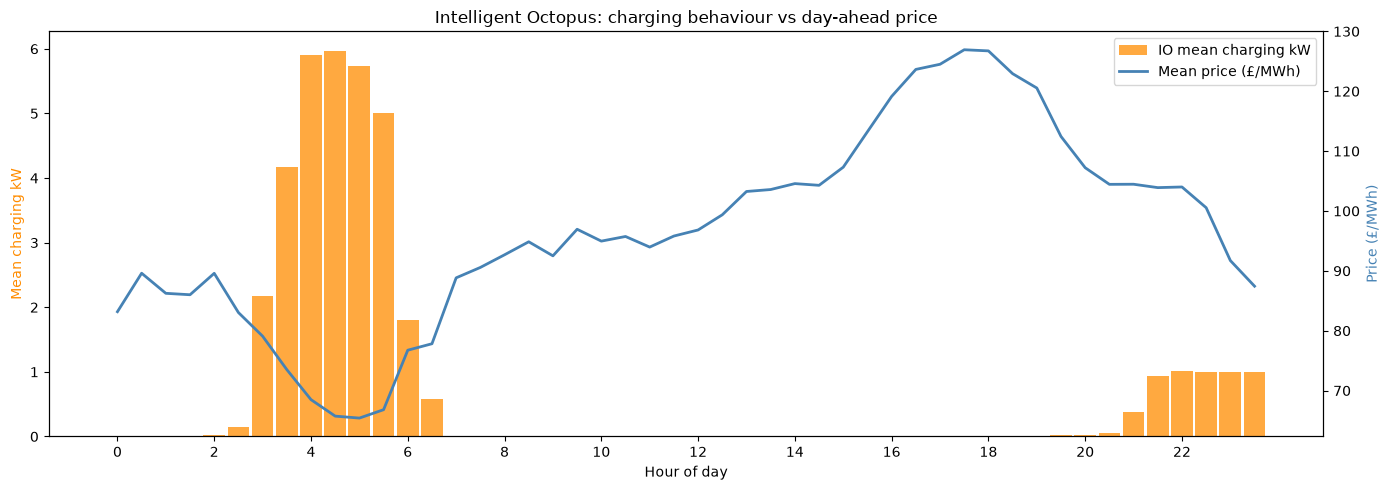

In [5]:
io_indices = [u.user_id for u in result.users if u.archetype.name == "Intelligent Octopus average"]
prices_flat = sim._prices  # (7, 48)

if prices_flat.max() == 0:
    print("Price data not available — run scripts/fetch_prices.py first.")
else:
    # Average IO charging across users and days → (48,) typical half-hour
    io_charging = result.charging_kw[io_indices]  # (n_io, 336)
    io_by_day = io_charging.reshape(-1, N_SIMULATION_DAYS, HALF_HOUR_PERIODS_PER_DAY)
    io_avg = io_by_day.mean(axis=(0, 1))  # (48,)

    avg_price = prices_flat.mean(axis=0)  # (48,) mean across the 7 days
    t_hod = np.arange(HALF_HOUR_PERIODS_PER_DAY) * 0.5

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    ax1.bar(t_hod, io_avg, width=0.45, color="darkorange", alpha=0.75, label="IO mean charging kW")
    ax2.plot(t_hod, avg_price, color="steelblue", linewidth=2, label="Mean price (£/MWh)")

    ax1.set_xlabel("Hour of day")
    ax1.set_ylabel("Mean charging kW", color="darkorange")
    ax2.set_ylabel("Price (£/MWh)", color="steelblue")
    ax1.set_title("Intelligent Octopus: charging behaviour vs day-ahead price")
    ax1.set_xticks(range(0, 24, 2))

    lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels)

    plt.tight_layout()
    plt.show()

## 5. Population-level event statistics

Total plug-in events: 12,824
Sessions with charging: 12,159
Truncated at week boundary (excluded from heatmaps): 1,851


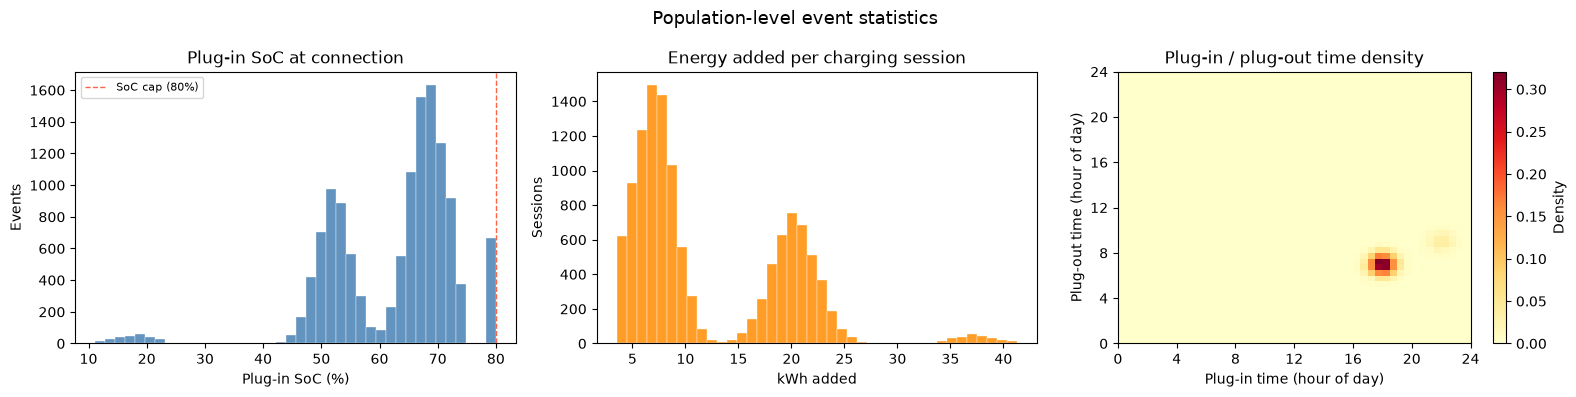

In [6]:
from ev_simulator.constants import SOC_CAP

n_users = len(result.users)

# Pad plugged_in with a False column at each end so every session has a detectable start and end,
# then diff to find rising (+1) and falling (-1) edges.
padded = np.zeros((n_users, N_PERIODS + 2), dtype=np.int8)
padded[:, 1:N_PERIODS + 1] = result.plugged_in.astype(np.int8)
diff = np.diff(padded, axis=1)  # (n_users, N_PERIODS + 1)

user_in,  period_in  = np.where(diff ==  1)  # plug-in period (inclusive start)
user_out, period_out = np.where(diff == -1)  # first un-plugged period (exclusive end)

plug_in_hod  = (period_in  % HALF_HOUR_PERIODS_PER_DAY) * 0.5
plug_out_hod = (period_out % HALF_HOUR_PERIODS_PER_DAY) * 0.5

plug_in_soc  = result.soc[user_in, period_in]

battery_caps  = np.array([result.users[u].archetype.battery_capacity_kwh for u in user_in])
kwh_topped    = np.maximum(SOC_CAP - plug_in_soc, 0.0) * battery_caps
needs_charge  = kwh_topped > 0

# Sessions truncated at the simulation week boundary produce a spurious plug-out at midnight;
# exclude them from heatmaps only (SoC and kWh plots are unaffected).
not_truncated = period_out < N_PERIODS

print(f"Total plug-in events: {len(period_in):,}")
print(f"Sessions with charging: {needs_charge.sum():,}")
print(f"Truncated at week boundary (excluded from heatmaps): {(~not_truncated).sum():,}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Population-level event statistics", fontsize=13)

# 1. Plug-in SoC distribution
ax = axes[0]
ax.hist(plug_in_soc * 100, bins=40, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.axvline(80, color="tomato", linestyle="--", linewidth=1, label="SoC cap (80%)")
ax.set_xlabel("Plug-in SoC (%)")
ax.set_ylabel("Events")
ax.set_title("Plug-in SoC at connection")
ax.legend(fontsize=8)

# 2. kWh added per charging session
ax = axes[1]
ax.hist(kwh_topped[needs_charge], bins=40, color="darkorange", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xlabel("kWh added")
ax.set_ylabel("Sessions")
ax.set_title("Energy added per charging session")

# 3. Plug-in vs plug-out time heatmap (truncated sessions excluded)
ax = axes[2]
_, _, _, img = ax.hist2d(
    plug_in_hod[not_truncated], plug_out_hod[not_truncated],
    bins=48,
    range=[[0, 24], [0, 24]],
    cmap="YlOrRd",
    density=True,
)
ax.set_xlabel("Plug-in time (hour of day)")
ax.set_ylabel("Plug-out time (hour of day)")
ax.set_title("Plug-in / plug-out time density")
ax.set_xticks(range(0, 25, 4))
ax.set_yticks(range(0, 25, 4))
fig.colorbar(img, ax=ax, label="Density")

plt.tight_layout()
plt.show()


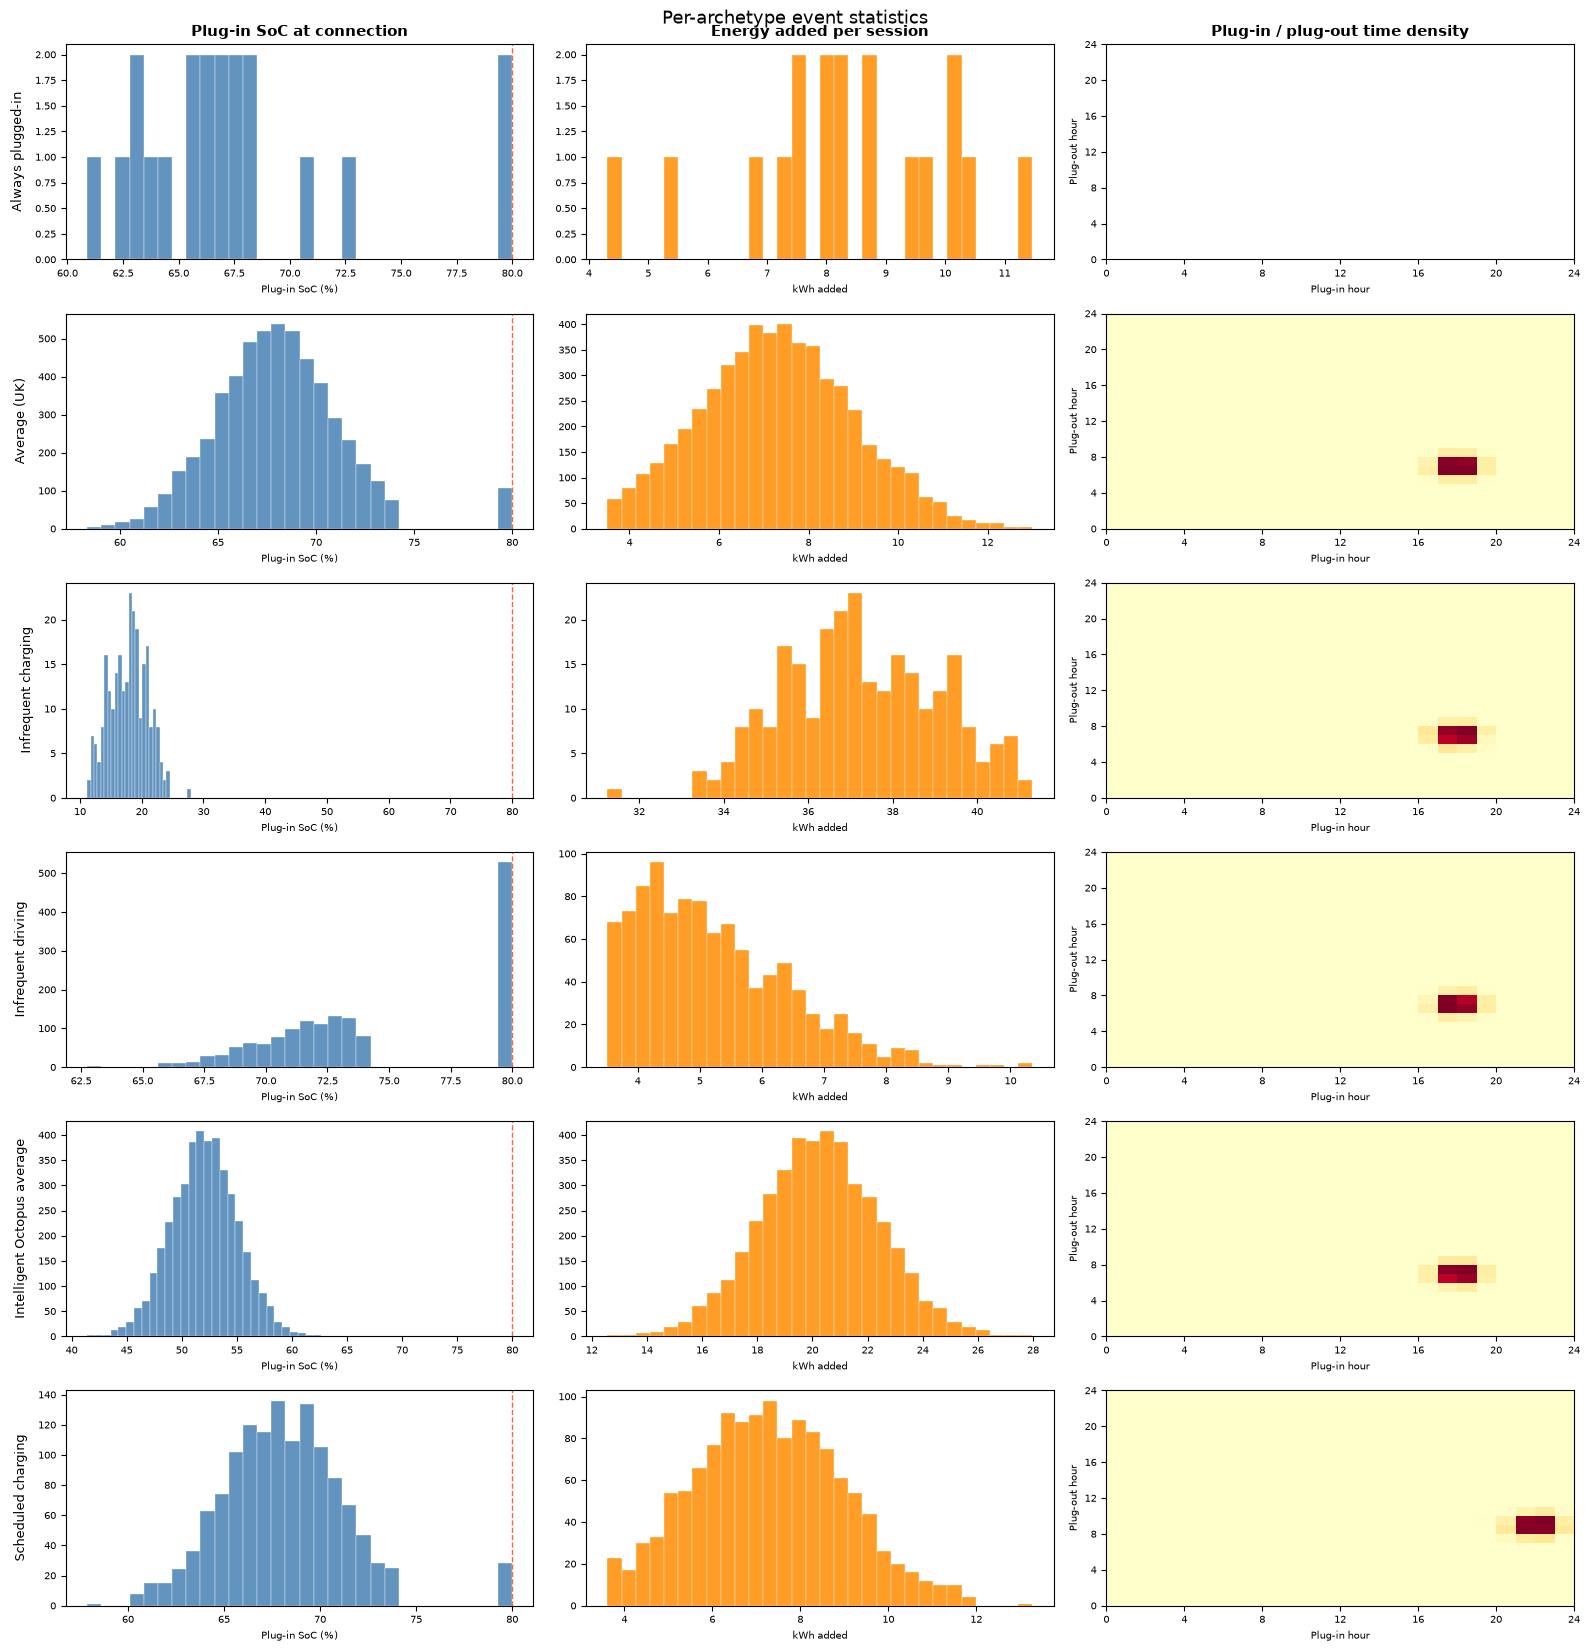

In [7]:
user_archetype = np.array([result.users[u].archetype.name for u in user_in])

fig, axes = plt.subplots(n_arch, 3, figsize=(16, 2.8 * n_arch), sharex=False)
fig.suptitle("Per-archetype event statistics", fontsize=13)

axes[0, 0].set_title("Plug-in SoC at connection",       fontsize=11, fontweight="bold")
axes[0, 1].set_title("Energy added per session",         fontsize=11, fontweight="bold")
axes[0, 2].set_title("Plug-in / plug-out time density",  fontsize=11, fontweight="bold")

for row, name in enumerate(arch_names):
    mask = user_archetype == name
    axes[row, 0].set_ylabel(name, fontsize=9, labelpad=8)

    # Plug-in SoC histogram
    ax = axes[row, 0]
    ax.hist(plug_in_soc[mask] * 100, bins=30, color="steelblue", alpha=0.85,
            edgecolor="white", linewidth=0.3)
    ax.axvline(80, color="tomato", linestyle="--", linewidth=1)
    ax.set_xlabel("Plug-in SoC (%)", fontsize=7)
    ax.tick_params(labelsize=7)

    # kWh topped up histogram
    ax = axes[row, 1]
    kwh_arch = kwh_topped[mask & needs_charge]
    if len(kwh_arch) > 0:
        ax.hist(kwh_arch, bins=30, color="darkorange", alpha=0.85,
                edgecolor="white", linewidth=0.3)
    else:
        ax.text(0.5, 0.5, "No charging sessions", transform=ax.transAxes,
                ha="center", va="center", fontsize=8, color="grey")
    ax.set_xlabel("kWh added", fontsize=7)
    ax.tick_params(labelsize=7)

    # Plug-in / plug-out heatmap (truncated sessions excluded)
    ax = axes[row, 2]
    heatmap_mask = mask & not_truncated
    hin  = plug_in_hod[heatmap_mask]
    hout = plug_out_hod[heatmap_mask]
    if len(hin) > 1:
        ax.hist2d(hin, hout, bins=24, range=[[0, 24], [0, 24]],
                  cmap="YlOrRd", density=True)
    ax.set_xlabel("Plug-in hour",  fontsize=7)
    ax.set_ylabel("Plug-out hour", fontsize=7)
    ax.set_xticks(range(0, 25, 4))
    ax.set_yticks(range(0, 25, 4))
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
